# ✅ Solutions — Module 11 — Logistic Regression & Generalised Linear Models

Worked solutions for every exercise of this module. **Try the exercise yourself first** — you learn statistics by *doing* it. Each solution ends with a short interpretation, because in real projects the numbers are only half of the answer.

*Every exercise is self-contained: run the setup cell below, then jump to any exercise.*

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve

### ✍️ Exercise 11.1 — *Logistic regression & odds ratios*: Who cancels their contract? (Telecom churn)

A telecom provider wants to understand which customers churn. For 3,000 customers you know tenure (months), monthly fee (€), contract type, number of support calls in the last quarter, and whether they churned.

**Tasks**
1. Compute the churn rate overall and by contract type.
2. Fit a logistic regression with all four predictors. Tabulate **odds ratios with 95 % CIs** and draw them as a forest plot (log scale).
3. Interpret: the odds ratio per support call; per **12 months** of tenure; of a two-year vs. a monthly contract.
4. Predict the churn probability for (a) a new monthly customer (tenure 3, fee €70, 3 support calls) and (b) a loyal two-year customer (tenure 48, fee €50, no calls).
5. Management concludes: "Move everybody to two-year contracts and churn will drop by 85 %." Comment.

In [2]:
g = np.random.default_rng(1101)
n = 3000
tel = pd.DataFrame({"tenure": g.gamma(2, 12, n).clip(1, 72).round(0), "fee": g.normal(55, 15, n).clip(20, 110).round(0),
                    "contract": pd.Categorical(g.choice(["monthly", "one-year", "two-year"], n, p=[.55, .25, .20]), categories=["monthly", "one-year", "two-year"]),
                    "support_calls": g.poisson(1.2, n)})
eta = -.4 - .045 * tel.tenure + .02 * (tel.fee - 55) + .45 * tel.support_calls + tel.contract.map({"monthly": 0, "one-year": -1.0, "two-year": -1.9}).astype(float)
tel["churn"] = (g.random(n) < 1 / (1 + np.exp(-eta))).astype(int)
tel.head()

,tenure,fee,contract,support_calls,churn
0,23.0,66.0,monthly,2,1
1,8.0,70.0,monthly,0,0
2,55.0,51.0,monthly,0,0
3,9.0,50.0,monthly,0,0
4,23.0,49.0,monthly,3,0


overall churn rate: 22.0%
contract
monthly     0.307
one-year    0.143
two-year    0.079
Name: churn, dtype: float64 

                      odds ratio  2.5 %  97.5 %
contract[T.one-year]       0.324  0.253   0.415
contract[T.two-year]       0.156  0.113   0.216
tenure                     0.951  0.943   0.958
fee                        1.018  1.011   1.024
support_calls              1.578  1.445   1.723

odds ratio for 12 more months of tenure: 0.54

predicted churn probability:
(a) new monthly customer       0.761
(b) loyal two-year customer    0.009
dtype: float64


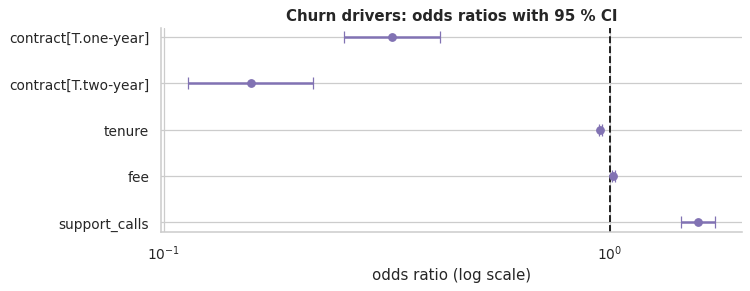

In [3]:
print(f"overall churn rate: {tel.churn.mean():.1%}"); print(tel.groupby("contract", observed=True).churn.mean().round(3), "\n")
m = smf.logit("churn ~ tenure + fee + contract + support_calls", tel).fit(disp=0)
ors = pd.concat([np.exp(m.params).rename("odds ratio"), np.exp(m.conf_int()).rename(columns={0: "2.5 %", 1: "97.5 %"})], axis=1).drop("Intercept"); print(ors.round(3))
print(f"\nodds ratio for 12 more months of tenure: {np.exp(12 * m.params['tenure']):.2f}")
profiles = pd.DataFrame({"tenure": [3, 48], "fee": [70, 50], "contract": ["monthly", "two-year"], "support_calls": [3, 0]}, index=["(a) new monthly customer", "(b) loyal two-year customer"])
print("\npredicted churn probability:"); print(m.predict(profiles).round(3))

fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.errorbar(ors["odds ratio"], range(len(ors)), xerr=[ors["odds ratio"] - ors["2.5 %"], ors["97.5 %"] - ors["odds ratio"]], fmt="o", color=C[4], capsize=5, lw=2)
ax.axvline(1, color="k", ls="--"); ax.set(xscale="log", yticks=range(len(ors)), yticklabels=ors.index, xlabel="odds ratio (log scale)", title="Churn drivers: odds ratios with 95 % CI"); ax.invert_yaxis(); plt.tight_layout(); plt.show()

**Interpretation.**
* **Support calls:** each call multiplies the odds of churning by ≈ 1.5–1.6 — three calls mean roughly a fourfold increase in odds. Calls are a *symptom* of problems, and a cheap early-warning signal.
* **Tenure:** per month the OR is ≈ 0.95, which looks negligible — but per **year** it is ≈ 0.54, almost a halving of the odds: odds ratios always refer to *one unit*, so choose meaningful units.
* **Contract:** two-year customers have about **85 % lower odds** of churning than monthly customers with the same tenure, fee and calls (OR ≈ 0.16).
* **Profiles:** the model turns these abstract ratios into concrete numbers: the new, unhappy monthly customer has a churn probability of about 76 %, the loyal two-year customer of about 1 %.

**On management's conclusion:** (1) 85 % lower *odds* is not 85 % lower *probability*. (2) More importantly, this is **observational** data: customers *chose* their contracts. People who sign for two years are those who intended to stay anyway (self-selection) — forcing a wobbly customer into a long contract does not transplant that loyalty. The causal effect of contract type can only be learned from an experiment, e.g. randomly offering incentives for longer contracts (Module 8).

### ✍️ Exercise 11.2 — *Thresholds & costs*: Whom should the bank lend to? (Credit scoring)

A bank scores loan applicants with a logistic regression. Approving a customer who later **defaults** costs on average **€5,000**; rejecting a customer who **would have repaid** loses **€600** of profit.

**Tasks**
1. Split the data (70 % training / 30 % test), fit the model on the training part and report the test AUC.
2. Show the confusion matrix at threshold 0.5. What share of the defaulters is caught?
3. For thresholds from 0.01 to 0.99, compute the **average cost per applicant** on the test set. Plot the cost curve and find the optimal threshold.
4. Compare with the theoretical optimum for a calibrated model, $t^*=\dfrac{c_{FP}}{c_{FP}+c_{FN}}$. How much money does the optimal threshold save per 10,000 applicants compared with 0.5 — and compared with approving everybody?

In [4]:
g = np.random.default_rng(1102)
n = 6000
loans = pd.DataFrame({"log_income": g.normal(10.6, .4, n).round(3), "debt_ratio": g.beta(2, 5, n).round(3), "late_payments": g.poisson(.6, n)})
eta = -2.2 - .9 * (loans.log_income - 10.6) + 3.2 * (loans.debt_ratio - .28) + .55 * loans.late_payments
loans["default"] = (g.random(n) < 1 / (1 + np.exp(-eta))).astype(int)
c_fn, c_fp = 5000, 600
print(f"default rate: {loans.default.mean():.1%}"); loans.head()

default rate: 17.0%


,log_income,debt_ratio,late_payments,default
0,10.840,0.274,1,0
1,11.055,0.155,0,0
2,10.022,0.178,0,1
3,10.307,0.315,0,0
4,10.172,0.437,0,1


test AUC = 0.658
threshold 0.5: TN = 1478, FP = 17, FN = 289, TP = 16  ->  only 5% of the defaulters are caught
optimal threshold = 0.10  (theory: 0.107);  cost per applicant: optimal 478 €, threshold 0.5: 808 €, approve everybody: 847 €
saving per 10,000 applicants: 3,306,667 € vs. threshold 0.5;  3,694,444 € vs. approving everybody


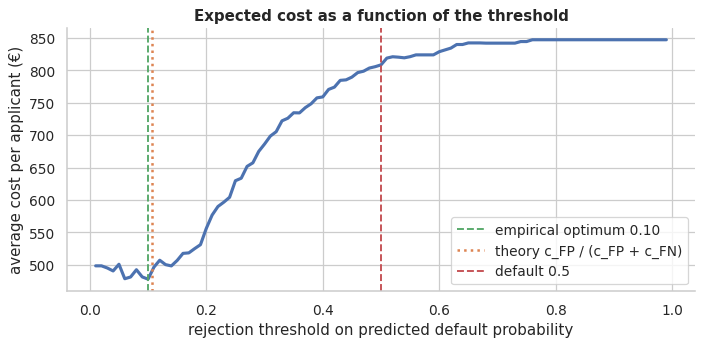

In [5]:
train, test = train_test_split(loans, test_size=.3, random_state=1, stratify=loans.default)
m = smf.logit("default ~ log_income + debt_ratio + late_payments", train).fit(disp=0)
p, y = m.predict(test).values, test.default.values
print(f"test AUC = {roc_auc_score(y, p):.3f}")
tn, fp, fn, tp = confusion_matrix(y, p >= .5).ravel(); print(f"threshold 0.5: TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}  ->  only {tp / (tp + fn):.0%} of the defaulters are caught")

thresholds = np.linspace(.01, .99, 99)
cost = np.array([(c_fn * ((p < t) & (y == 1)).sum() + c_fp * ((p >= t) & (y == 0)).sum()) / y.size for t in thresholds])     # reject if p >= t
t_best = thresholds[cost.argmin()]; cost_05 = cost[np.abs(thresholds - .5).argmin()]; cost_all = c_fn * y.mean()
print(f"optimal threshold = {t_best:.2f}  (theory: {c_fp / (c_fp + c_fn):.3f});  cost per applicant: optimal {cost.min():.0f} €, threshold 0.5: {cost_05:.0f} €, approve everybody: {cost_all:.0f} €")
print(f"saving per 10,000 applicants: {(cost_05 - cost.min()) * 10_000:,.0f} € vs. threshold 0.5;  {(cost_all - cost.min()) * 10_000:,.0f} € vs. approving everybody")
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(thresholds, cost, color=C[0], lw=2.5); ax.axvline(t_best, color=C[2], ls="--", label=f"empirical optimum {t_best:.2f}"); ax.axvline(c_fp / (c_fp + c_fn), color=C[1], ls=":", lw=2, label="theory c_FP / (c_FP + c_FN)"); ax.axvline(.5, color=C[3], ls="--", label="default 0.5")
ax.set(xlabel="rejection threshold on predicted default probability", ylabel="average cost per applicant (€)", title="Expected cost as a function of the threshold"); ax.legend(); plt.show()

**Interpretation.** The model ranks applicants only moderately well (AUC ≈ 0.66 — credit risk is hard to predict), yet at the conventional threshold of 0.5 it rejects almost nobody and catches only a small fraction of the defaulters — hardly better than approving everybody. Because a missed defaulter is about eight times as expensive as a wrongly rejected good customer, the cost-minimising threshold is **far lower**: around 0.1, close to the theoretical value $600/5600\approx0.107$. The cost curve is flat near its minimum, so the exact value matters little — but moving from 0.5 to ≈ 0.1 cuts the expected cost per applicant from about €810 to €480 — more than €3 million per 10,000 applicants. Even a mediocre model is worth a lot of money when it is used with the right threshold.

**Lesson:** the classifier delivers probabilities; the **threshold is a business decision** derived from costs and benefits. The formula $t^*=c_{FP}/(c_{FP}+c_{FN})$ only works if the probabilities are **calibrated** — one more reason to check calibration, not just AUC.

### ✍️ Exercise 11.3 — *ROC, cross-validation & sensitivity*: A diagnostic model for breast cancer (Medicine, real data)

The Wisconsin breast-cancer data contain 30 measurements of cell nuclei from 569 biopsies, with the diagnosis (malignant / benign).

**Tasks**
1. Split the data (stratified, 30 % test). Build a pipeline *standardise → logistic regression* and estimate its AUC by 5-fold cross-validation **on the training set**.
2. Evaluate on the test set: AUC and confusion matrix at threshold 0.5.
3. In cancer diagnostics a missed tumour is far worse than an unnecessary follow-up. Report sensitivity and specificity at thresholds 0.5 and 0.1.
4. Which five features have the largest standardised coefficients? Why should you be careful when interpreting them? (Hint: Module 10.)

In [6]:
bc = load_breast_cancer(as_frame=True)
X, y = bc.data, (bc.target == 0).astype(int)                    # sklearn codes malignant as 0 -> we recode: 1 = malignant
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=0, stratify=y)
print(X.shape, f"share malignant: {y.mean():.1%}")

(569, 30) share malignant: 37.3%


5-fold CV AUC on the training set: 0.9974 ± 0.0046
test AUC = 0.9917

threshold 0.5: TN = 103, FP =  4, FN =  4, TP = 60   sensitivity = 0.938, specificity = 0.963
threshold 0.1: TN =  93, FP = 14, FN =  1, TP = 63   sensitivity = 0.984, specificity = 0.869

largest standardised coefficients:
radius error           1.26
worst radius           1.03
mean concave points    0.94
worst symmetry         0.94
compactness error     -0.93
dtype: float64

correlation between 'mean radius' and 'mean perimeter': 0.998


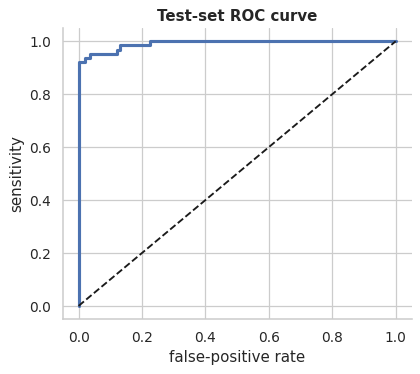

In [7]:
pipe = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=5000))
cv_auc = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc"); print(f"5-fold CV AUC on the training set: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
pipe.fit(X_train, y_train); p = pipe.predict_proba(X_test)[:, 1]; print(f"test AUC = {roc_auc_score(y_test, p):.4f}\n")
for t in [.5, .1]:
    tn, fp, fn, tp = confusion_matrix(y_test, p >= t).ravel()
    print(f"threshold {t}: TN = {tn:3d}, FP = {fp:2d}, FN = {fn:2d}, TP = {tp:2d}   sensitivity = {tp / (tp + fn):.3f}, specificity = {tn / (tn + fp):.3f}")
coef = pd.Series(pipe[-1].coef_[0], index=X.columns); print("\nlargest standardised coefficients:"); print(coef.sort_values(key=abs, ascending=False).head(5).round(2))
print(f"\ncorrelation between 'mean radius' and 'mean perimeter': {X['mean radius'].corr(X['mean perimeter']):.3f}")
fpr, tpr, _ = roc_curve(y_test, p); fig, ax = plt.subplots(figsize=(5, 4.2)); ax.plot(fpr, tpr, color=C[0], lw=2.5); ax.plot([0, 1], [0, 1], "k--"); ax.set(xlabel="false-positive rate", ylabel="sensitivity", title="Test-set ROC curve"); plt.show()

**Interpretation.** The cross-validated AUC (≈ 0.99) and the test AUC agree — the hallmark of an honest evaluation: CV on the training data gives an estimate *before* the test set is touched, and the test set then confirms it. At threshold 0.5 the model already finds the large majority of tumours with very few false alarms; lowering the threshold to 0.1 raises the **sensitivity** from 94 % to 98 % (one missed tumour instead of four) at the price of ten additional false positives — in a screening setting that trade is clearly worth making, since a false positive means a follow-up examination while a false negative means an untreated cancer.

**Coefficients:** the largest standardised coefficients belong to size- and texture-related features, but do not read them as "the most important causes": many of the 30 features are nearly duplicates of each other (radius, perimeter and area correlate above 0.99), so the model can shift weight among them almost arbitrarily — **multicollinearity** (Module 10). The default L2 penalty of scikit-learn's `LogisticRegression` is a ridge penalty that keeps such coefficients stable; it also handles the fact that the classes are almost perfectly separable, a situation in which unpenalised maximum likelihood would push coefficients towards infinity.

### ✍️ Exercise 11.4 — *Poisson regression with exposure*: Pricing motor insurance (Actuarial science)

An insurer analyses the **claim frequency** of 8,000 motor policies. Policies were in force for different fractions of the year (`exposure`). Predictors: driver's age group and engine power.

**Tasks**
1. Compute the crude claim frequency (claims per policy-year) by age group — once correctly (total claims / total exposure) and once naively (mean number of claims per policy). What goes wrong with the naive version?
2. Fit a Poisson GLM with `offset = log(exposure)`. Tabulate the **rate ratios** with 95 % CIs (reference: age 26–40, low power).
3. What is the expected number of claims per year for an 18–25-year-old with a high-powered car, and for a 41–65-year-old with a low-powered car?
4. Check the dispersion statistic. Then refit **without** the offset and compare the rate ratio of the young drivers. Explain.

In [8]:
g = np.random.default_rng(1104)
n = 8000
mot = pd.DataFrame({"age_group": pd.Categorical(g.choice(["26-40", "18-25", "41-65", "66+"], n, p=[.35, .12, .40, .13]), categories=["26-40", "18-25", "41-65", "66+"]),
                    "power": pd.Categorical(g.choice(["low", "medium", "high"], n, p=[.4, .4, .2]), categories=["low", "medium", "high"])})
mot["exposure"] = np.where(mot.age_group == "18-25", g.uniform(.1, .6, n), g.uniform(.3, 1, n)).round(2)          # young drivers: mostly new, short-running policies
rate = .08 * mot.age_group.map({"26-40": 1.0, "18-25": 2.2, "41-65": .8, "66+": 1.3}).astype(float) * mot.power.map({"low": 1.0, "medium": 1.25, "high": 1.7}).astype(float)
mot["claims"] = g.poisson(rate * mot.exposure)
mot.head()

,age_group,power,exposure,claims
0,26-40,medium,0.79,0
1,26-40,low,0.58,0
2,41-65,high,0.36,0
3,41-65,high,0.69,0
4,41-65,low,0.64,0


           policies  claims  exposure  claims per policy-year (correct)  \
age_group                                                                 
26-40          2782     183   1786.16                             0.102   
18-25           973      78    328.37                             0.238   
41-65          3175     167   2085.38                             0.080   
66+            1070      86    689.20                             0.125   

           claims per policy (naive)  
age_group                             
26-40                          0.066  
18-25                          0.080  
41-65                          0.053  
66+                            0.080   

                    rate ratio  2.5 %  97.5 %
Intercept                0.084  0.069   0.101
age_group[T.18-25]       2.304  1.768   3.003
age_group[T.41-65]       0.782  0.634   0.965
age_group[T.66+]         1.232  0.954   1.593
power[T.medium]          1.235  1.008   1.514
power[T.high]            1.633  1.304

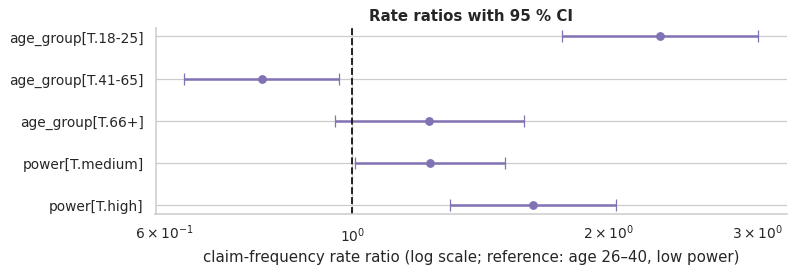

In [9]:
by_age = mot.groupby("age_group", observed=True).agg(policies=("claims", "size"), claims=("claims", "sum"), exposure=("exposure", "sum"))
by_age["claims per policy-year (correct)"] = by_age.claims / by_age.exposure; by_age["claims per policy (naive)"] = by_age.claims / by_age.policies; print(by_age.round(3), "\n")

m = smf.glm("claims ~ age_group + power", data=mot, family=sm.families.Poisson(), offset=np.log(mot.exposure)).fit()
rr = pd.concat([np.exp(m.params).rename("rate ratio"), np.exp(m.conf_int()).rename(columns={0: "2.5 %", 1: "97.5 %"})], axis=1); print(rr.round(3))
new = pd.DataFrame({"age_group": ["18-25", "41-65"], "power": ["high", "low"]})
print("\nexpected claims per full policy-year:", m.predict(new, offset=np.log([1.0, 1.0])).round(3).tolist())
print(f"dispersion statistic: {m.pearson_chi2 / m.df_resid:.2f}")
m_no = smf.glm("claims ~ age_group + power", data=mot, family=sm.families.Poisson()).fit()
print(f"\nrate ratio 18-25 vs 26-40:  with offset {np.exp(m.params['age_group[T.18-25]']):.2f}   |   WITHOUT offset {np.exp(m_no.params['age_group[T.18-25]']):.2f}   (truth: 2.20)")
r = rr.drop("Intercept"); fig, ax = plt.subplots(figsize=(9, 3.2))
ax.errorbar(r["rate ratio"], range(len(r)), xerr=[r["rate ratio"] - r["2.5 %"], r["97.5 %"] - r["rate ratio"]], fmt="o", color=C[4], capsize=5, lw=2)
ax.axvline(1, color="k", ls="--"); ax.set(xscale="log", yticks=range(len(r)), yticklabels=r.index, xlabel="claim-frequency rate ratio (log scale; reference: age 26–40, low power)", title="Rate ratios with 95 % CI"); ax.invert_yaxis(); plt.tight_layout(); plt.show()

**Interpretation.**
* **Exposure matters.** Young drivers' policies ran on average only about a third of a year. Counting claims *per policy* therefore makes them look barely riskier than everybody else; per **policy-year** their claim frequency is more than twice that of the 26–40 group.
* **Rate ratios:** the GLM recovers the structure built into the data — 18–25-year-olds ≈ 2.2 × the reference frequency, 41–65 ≈ 0.8 ×, 66+ ≈ 1.3 ×; medium power ≈ 1.25 ×, high power ≈ 1.7 ×. Because the model is multiplicative, a young driver with a powerful car has about $2.2\times1.7\approx3.7$ times the base frequency: ≈ 0.3 expected claims per year versus ≈ 0.06 for the middle-aged driver of a small car — a factor of five in the pure premium.
* **Dispersion ≈ 1:** no sign of overdispersion here, so the Poisson standard errors can be trusted.
* **Without the offset** the young-driver effect is badly underestimated, because the model confuses "few claims" with "short observation time". Whenever counts come from unequal observation windows, populations or distances, the **offset is not optional**.